# Práctica 1: Comparación estadística y diagramas de caja

**Universidad CENFOTEC** · Escuela de Fundamentos  
**Curso:** Probabilidad y Estadística 2 · III Cuatrimestre 2026  
**Docente:** Kevin Eduardo Cervantes Melgar  
**Actividad:** Análisis descriptivo (10 % de la nota final) · Modalidad individual

## Objetivo

Aplicar tendencia central, dispersión y posición al dataset de Gapminder, y contrastar dos países —**Costa Rica** y **China**— con diagramas de caja. Las variables de trabajo son:

- `gdpPercap`: PIB per cápita en dólares ajustados por inflación (paridad de poder adquisitivo).
- `lifeExp`: esperanza de vida al nacer, en años.
- `pop`: población, en habitantes.


## 1. Carga y verificación de los datos


In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

DATA_PATH = Path("gapminder_all.csv")
ancho = pd.read_csv(DATA_PATH)
ANIOS = [1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002, 2007]

df = pd.concat(
    [
        pd.DataFrame(
            {
                "continent": ancho["continent"],
                "country": ancho["country"],
                "year": anio,
                "gdpPercap": ancho[f"gdpPercap_{anio}"],
                "lifeExp": ancho[f"lifeExp_{anio}"],
                "pop": ancho[f"pop_{anio}"],
            }
        )
        for anio in ANIOS
    ],
    ignore_index=True,
)

VARIABLES = ["gdpPercap", "lifeExp", "pop"]
ETIQUETAS = {
    "gdpPercap": "PIB per cápita (USD PPA)",
    "lifeExp": "Esperanza de vida (años)",
    "pop": "Población (habitantes)",
}
PAISES = ["Costa Rica", "China"]

df["year"] = df["year"].astype(int)
assert set(VARIABLES).issubset(df.columns)
assert set(PAISES).issubset(df["country"].unique())

print(f"Observaciones: {len(df):,}".replace(",", " "))
print(f"Países: {df['country'].nunique()}")
print(f"Años: {df['year'].min()}–{df['year'].max()} ({df['year'].nunique()} cortes)")
print(f"Continentes: {', '.join(sorted(df['continent'].unique()))}")
df.head()


Observaciones: 1 704
Países: 142
Años: 1952–2007 (12 cortes)
Continentes: Africa, Americas, Asia, Europe, Oceania


,continent,country,year,gdpPercap,lifeExp,pop
0,Africa,Algeria,1952,2449.008185,43.077,9279525.0
1,Africa,Angola,1952,3520.610273,30.015,4232095.0
2,Africa,Benin,1952,1062.752200,38.223,1738315.0
3,Africa,Botswana,1952,851.241141,47.622,442308.0
4,Africa,Burkina Faso,1952,543.255241,31.975,4469979.0


## 2. Estadísticas descriptivas del panel completo

Observación país-año: Registras el dato de cada país en cada año (ej. Chile en 2010, Chile en 2011). 50 países en 34 años suman 1 704 datos en total.$n - 1$: Indica que usaron la fórmula calculada para una muestra de datos, en lugar de toda la población mundial histórica.Desviación estándar: Mide qué tan dispersos están los datos del promedio. Si es baja, los países son similares; si es alta, hay diferencias gigantes.Mediana ($Q_2$): El dato que queda justo al centro ($50\%$) al ordenarlos de menor a mayor.Cuartiles ($Q_1$ y $Q_3$): Marcas que dividen los datos ordenados en partes: $Q_1$ deja atrás al $25\%$ más bajo y $Q_3$ al $75\%$.IQR ($Q_3 - Q_1$): El ancho del rango donde se concentra el $50\%$ central de los datos.


In [3]:
def resumen(serie: pd.Series) -> pd.Series:
    q1, q2, q3 = serie.quantile([0.25, 0.50, 0.75])
    iqr = q3 - q1
    cerca_inf = q1 - 1.5 * iqr
    cerca_sup = q3 + 1.5 * iqr
    n_atipicos = int(((serie < cerca_inf) | (serie > cerca_sup)).sum())
    return pd.Series(
        {
            "n": int(serie.count()),
            "Media": serie.mean(),
            "Mediana (Q2)": q2,
            "Desv. estándar": serie.std(ddof=1),
            "Mínimo": serie.min(),
            "Máximo": serie.max(),
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Cerca inferior": cerca_inf,
            "Cerca superior": cerca_sup,
            "Atípicos (Tukey)": n_atipicos,
            "Asimetría (Fisher)": serie.skew(),
        }
    )


tabla_global = pd.DataFrame({ETIQUETAS[v]: resumen(df[v]) for v in VARIABLES})
tabla_global


,PIB per cápita (USD PPA),Esperanza de vida (años),Población (habitantes)
n,1704.000000,1704.000000,1.704000e+03
Media,7215.327081,59.474439,2.960121e+07
Mediana (Q2),3531.846988,60.712500,7.023596e+06
Desv. estándar,9857.454543,12.917107,1.061579e+08
Mínimo,241.165876,23.599000,6.001100e+04
Máximo,113523.132900,82.603000,1.318683e+09
Q1,1202.060309,48.198000,2.793664e+06
Q3,9325.462346,70.845500,1.958522e+07
IQR,8123.402037,22.647500,1.679156e+07
Cerca inferior,-10983.042746,14.226750,-2.239367e+07


In [4]:
def formato_tabla(tabla: pd.DataFrame) -> pd.DataFrame:
    salida = tabla.copy()
    for col in salida.columns:
        if "Esperanza" in col:
            salida[col] = salida[col].map(lambda x: f"{x:,.2f}")
        elif "PIB" in col:
            salida[col] = salida[col].map(lambda x: f"{x:,.2f}")
        else:
            salida[col] = salida[col].map(lambda x: f"{x:,.2f}")
    # Conteos enteros
    for col in salida.columns:
        for fila in ("n", "Atípicos (Tukey)"):
            salida.loc[fila, col] = f"{float(tabla.loc[fila, col]):,.0f}"
    return salida


formato_tabla(tabla_global)


,PIB per cápita (USD PPA),Esperanza de vida (años),Población (habitantes)
n,"1,704","1,704","1,704"
Media,"7,215.33",59.47,"29,601,212.33"
Mediana (Q2),"3,531.85",60.71,"7,023,595.50"
Desv. estándar,"9,857.45",12.92,"106,157,896.75"
Mínimo,241.17,23.60,"60,011.00"
Máximo,"113,523.13",82.60,"1,318,683,096.00"
Q1,"1,202.06",48.20,"2,793,664.00"
Q3,"9,325.46",70.85,"19,585,221.75"
IQR,"8,123.40",22.65,"16,791,557.75"
Cerca inferior,"-10,983.04",14.23,"-22,393,672.62"


Lectura inmediata de la tabla, antes de los gráficos:

- En **esperanza de vida** la media (59.47 años) queda 1.24 años por debajo de la mediana (60.71). La asimetría de Fisher es −0.25: leve cola izquierda.
- En **PIB per cápita** la media (7 215 USD) es aproximadamente el doble de la mediana (3 532 USD). La asimetría de Fisher es 3.85: cola derecha marcada.
- En **población** la media (29.6 millones) es 4.2 veces la mediana (7.02 millones). La asimetría de Fisher es 8.34, la más extrema de las tres variables.

El detalle de simetría y de valores atípicos se desarrolla en la sección 5, junto con los diagramas de caja.


## 3. Comparación estructurada: Costa Rica y China

Se eligen dos países presentes en los doce cortes del panel:

- **Costa Rica** (Américas): país pequeño, con trayectoria social y sanitaria temprana.
- **China** (Asia): el país de mayor población del panel y un cambio de régimen de crecimiento muy visible a partir de las reformas de finales de los años setenta.

La comparación usa la serie completa 1952–2007 de cada país (12 observaciones) y, además, el corte de 2007 para situar el punto final.


In [5]:
paises = df[df["country"].isin(PAISES)].copy()

tablas_pais = {}
for pais in PAISES:
    sub = paises[paises["country"] == pais]
    tablas_pais[pais] = pd.DataFrame({ETIQUETAS[v]: resumen(sub[v]) for v in VARIABLES})

comparacion = pd.concat(tablas_pais, axis=1)
comparacion


Costa Rica                           \
                   PIB per cápita (USD PPA) Esperanza de vida (años)   
n                                 12.000000                12.000000   
Media                           5448.610779                70.181417   
Mediana (Q2)                    5446.325034                72.100000   
Desv. estándar                  2018.532901                 7.404390   
Mínimo                          2627.009471                57.206000   
Máximo                          9645.061420                78.782000   
Q1                              3986.530132                64.778500   
Q3                              6289.573566                76.099750   
IQR                             2303.043434                11.321250   
Cerca inferior                   531.964980                47.796625   
Cerca superior                  9744.138718                93.081625   
Atípicos (Tukey)                   0.000000                 0.000000   
Asimetría (Fisher)                 0.539189                -0.525656   

                                                             China  \
                   Población (habitantes) PIB per cápita (USD PPA)   
n                            1.200000e+01                12.000000   
Media                        2.400008e+06              1488.307694   
Mediana (Q2)                 2.266412e+06               851.829425   
Desv. estándar               1.090414e+06              1370.628333   
Mínimo                       9.263170e+05               400.448611   
Máximo                       4.133884e+06              4959.114854   
Q1                           1.527834e+06               603.526020   
Q3                           3.259439e+06              1814.146653   
IQR                          1.731604e+06              1210.620632   
Cerca inferior              -1.069572e+06             -1212.404928   
Cerca superior               5.856845e+06              3630.077601   
Atípicos (Tukey)             0.000000e+00                 1.000000   
Asimetría (Fisher)           2.391618e-01                 1.773074   

                                                                    
                   Esperanza de vida (años) Población (habitantes)  
n                                 12.000000           1.200000e+01  
Media                             61.785140           9.581601e+08  
Mediana (Q2)                      64.746180           9.718680e+08  
Desv. estándar                    10.250020           2.643949e+08  
Mínimo                            44.000000           5.562635e+08  
Máximo                            72.961000           1.318683e+09  
Q1                                56.423080           7.323550e+08  
Q3                                69.124000           1.181246e+09  
IQR                               12.700920           4.488912e+08  
Cerca inferior                    37.371700           5.901812e+07  
Cerca superior                    88.175380           1.854583e+09  
Atípicos (Tukey)                   0.000000           0.000000e+00  
Asimetría (Fisher)                -0.868305          -1.233837e-01

In [6]:
def bloque(pais: str) -> pd.DataFrame:
    return formato_tabla(tablas_pais[pais])


print("Costa Rica")
display(bloque("Costa Rica"))
print("China")
display(bloque("China"))


Costa Rica


,PIB per cápita (USD PPA),Esperanza de vida (años),Población (habitantes)
n,12,12,12
Media,"5,448.61",70.18,"2,400,007.75"
Mediana (Q2),"5,446.33",72.10,"2,266,412.00"
Desv. estándar,"2,018.53",7.40,"1,090,414.20"
Mínimo,"2,627.01",57.21,"926,317.00"
Máximo,"9,645.06",78.78,"4,133,884.00"
Q1,"3,986.53",64.78,"1,527,834.50"
Q3,"6,289.57",76.10,"3,259,438.75"
IQR,"2,303.04",11.32,"1,731,604.25"
Cerca inferior,531.96,47.80,"-1,069,571.88"


China


,PIB per cápita (USD PPA),Esperanza de vida (años),Población (habitantes)
n,12,12,12
Media,"1,488.31",61.79,"958,160,052.00"
Mediana (Q2),851.83,64.75,"971,868,000.00"
Desv. estándar,"1,370.63",10.25,"264,394,872.69"
Mínimo,400.45,44.00,"556,263,528.00"
Máximo,"4,959.11",72.96,"1,318,683,096.00"
Q1,603.53,56.42,"732,355,000.00"
Q3,"1,814.15",69.12,"1,181,246,250.00"
IQR,"1,210.62",12.70,"448,891,250.00"
Cerca inferior,"-1,212.40",37.37,"59,018,125.00"


In [7]:
cr = paises[paises["country"] == "Costa Rica"].set_index("year")
cn = paises[paises["country"] == "China"].set_index("year")

filas = []
for variable, etiqueta in ETIQUETAS.items():
    media_cr, media_cn = cr[variable].mean(), cn[variable].mean()
    med_cr, med_cn = cr[variable].median(), cn[variable].median()
    v2007_cr, v2007_cn = cr.loc[2007, variable], cn.loc[2007, variable]
    filas.append(
        {
            "Indicador": etiqueta,
            "Media Costa Rica": media_cr,
            "Media China": media_cn,
            "Diferencia de medias (CR − CN)": media_cr - media_cn,
            "Razón de medias (CR / CN)": media_cr / media_cn,
            "Mediana Costa Rica": med_cr,
            "Mediana China": med_cn,
            "2007 Costa Rica": v2007_cr,
            "2007 China": v2007_cn,
            "Razón 2007 (CR / CN)": v2007_cr / v2007_cn,
            "Razón 2007 (CN / CR)": v2007_cn / v2007_cr,
            "Variación 1952–2007 CR": cr.loc[2007, variable] / cr.loc[1952, variable] - 1,
            "Variación 1952–2007 CN": cn.loc[2007, variable] / cn.loc[1952, variable] - 1,
        }
    )

contraste = pd.DataFrame(filas).set_index("Indicador")
contraste.round(3)


,Media Costa Rica,Media China,Diferencia de medias (CR − CN),Razón de medias (CR / CN),Mediana Costa Rica,Mediana China,2007 Costa Rica,2007 China,Razón 2007 (CR / CN),Razón 2007 (CN / CR),Variación 1952–2007 CR,Variación 1952–2007 CN
Indicador,,,,,,,,,,,,
PIB per cápita (USD PPA),5448.611,1.488308e+03,3.960303e+03,3.661,5446.325,8.518290e+02,9645.061,4.959115e+03,1.945,0.514,2.671,11.384
Esperanza de vida (años),70.181,6.178500e+01,8.396000e+00,1.136,72.100,6.474600e+01,78.782,7.296100e+01,1.080,0.926,0.377,0.658
Población (habitantes),2400007.750,9.581601e+08,-9.557600e+08,0.003,2266412.000,9.718680e+08,4133884.000,1.318683e+09,0.003,318.994,3.463,1.371


In [8]:
serie = paises.pivot(index="year", columns="country", values=VARIABLES)
serie = serie.reorder_levels([1, 0], axis=1).sort_index(axis=1)
serie.round(2)


country     China                       Costa Rica                   
        gdpPercap lifeExp           pop  gdpPercap lifeExp        pop
year                                                                 
1952       400.45   44.00  5.562635e+08    2627.01   57.21   926317.0
1957       575.99   50.55  6.374080e+08    2990.01   60.03  1112300.0
1962       487.67   44.50  6.657700e+08    3460.94   62.84  1345187.0
1967       612.71   58.38  7.545500e+08    4161.73   65.42  1588717.0
1972       676.90   63.12  8.620300e+08    5118.15   67.85  1834796.0
1977       741.24   63.97  9.434550e+08    5926.88   70.75  2108457.0
1982       962.42   65.53  1.000281e+09    5262.73   73.45  2424367.0
1987      1378.90   67.27  1.084035e+09    5629.92   74.75  2799811.0
1992      1655.78   68.69  1.164970e+09    6160.42   75.71  3173216.0
1997      2289.23   70.43  1.230075e+09    6677.05   77.26  3518107.0
2002      3119.28   72.03  1.280400e+09    7723.45   78.12  3834934.0
2007      4959.11   72.96  1.318683e+09    9645.06   78.78  4133884.0

Magnitudes que ordenan el contraste (se retoman en la sección 5):

| Hecho | Cifra |
| --- | --- |
| Población media | China es 399 veces Costa Rica (958 millones frente a 2.40 millones) |
| Población en 2007 | China es 319 veces Costa Rica (1 319 millones frente a 4.13 millones) |
| PIB per cápita medio | Costa Rica es 3.66 veces China (5 449 USD frente a 1 488 USD) |
| PIB per cápita en 2007 | Costa Rica es 1.94 veces China (9 645 USD frente a 4 959 USD) |
| Multiplicación del PIB per cápita, 1952–2007 | China ×12.38; Costa Rica ×3.67 |
| Esperanza de vida media | Costa Rica supera a China en 8.40 años (70.18 frente a 61.79) |
| Esperanza de vida en 2007 | Costa Rica supera a China en 5.82 años (78.78 frente a 72.96) |
| Ganancia de esperanza de vida, 1952–2007 | China +28.96 años; Costa Rica +21.58 años |

China cierra parte de la brecha, pero no la invierte: en 2007 Costa Rica sigue por encima en ingreso por persona y en longevidad, y muy por debajo en escala demográfica.


## 4. Diagramas de caja

Se construyen dos familias de gráficos.

1. **Corte transversal de 2007**, por continente. Compara países en el mismo año y evita mezclar décadas dentro de la misma caja. Oceanía tiene solo dos países (Australia y Nueva Zelanda): su caja es poco informativa y se lee como referencia, no como distribución.
2. **Series nacionales 1952–2007** de Costa Rica y China. Cada caja resume los doce quinquenios del país. La población se grafica en escala logarítmica: en escala lineal la caja de Costa Rica colapsa contra el cero, porque China es cerca de 400 veces más grande.


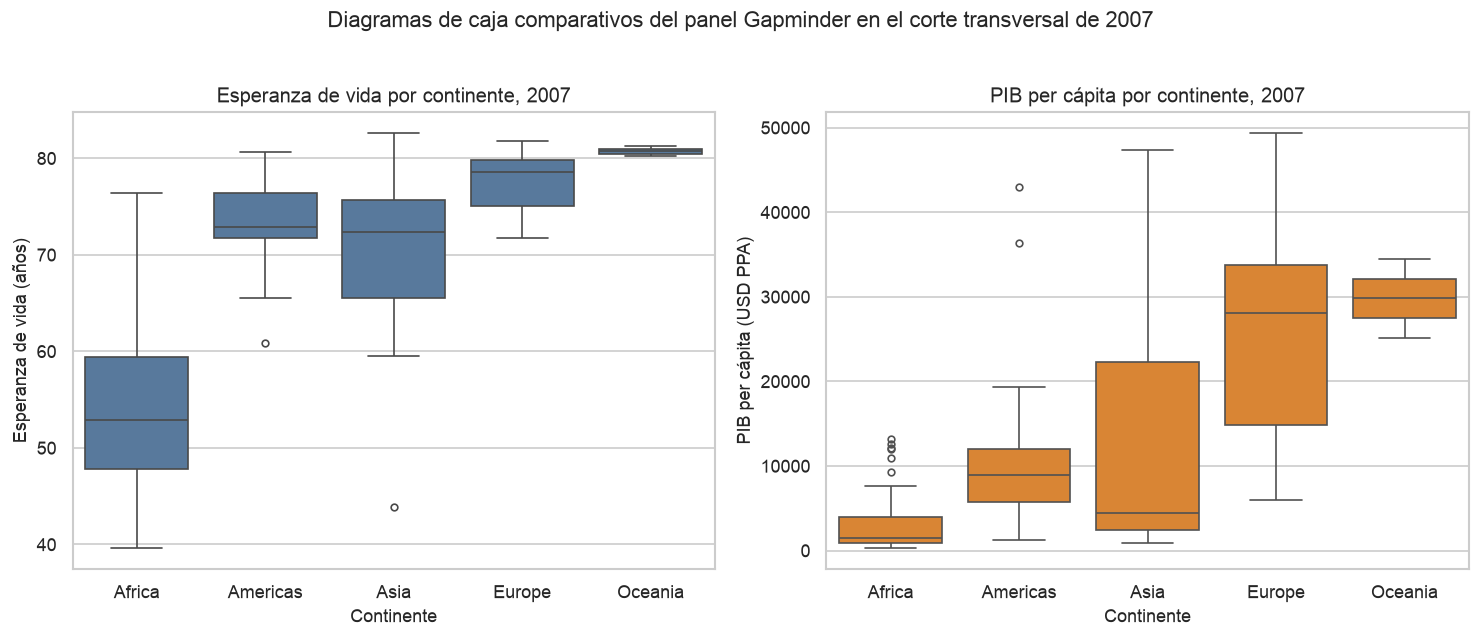

Resumen 2007 por continente — esperanza de vida (años)


,n,media,mediana,desv,minimo,maximo
continent,,,,,,
Africa,52,54.81,52.93,9.63,39.61,76.44
Americas,25,73.61,72.90,4.44,60.92,80.65
Asia,33,70.73,72.40,7.96,43.83,82.60
Europe,30,77.65,78.61,2.98,71.78,81.76
Oceania,2,80.72,80.72,0.73,80.20,81.24


Resumen 2007 por continente — PIB per cápita (USD PPA)


,n,media,mediana,desv,minimo,maximo
continent,,,,,,
Africa,52,3089.03,1452.27,3618.16,277.55,13206.48
Americas,25,11003.03,8948.10,9713.21,1201.64,42951.65
Asia,33,12473.03,4471.06,14154.94,944.00,47306.99
Europe,30,25054.48,28054.07,11800.34,5937.03,49357.19
Oceania,2,29810.19,29810.19,6540.99,25185.01,34435.37


In [9]:
corte_2007 = df[df["year"] == 2007].copy()
orden_continentes = ["Africa", "Americas", "Asia", "Europe", "Oceania"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

sns.boxplot(
    data=corte_2007,
    x="continent",
    y="lifeExp",
    order=orden_continentes,
    ax=axes[0],
    color="#4C78A8",
    fliersize=4,
)
axes[0].set_title("Esperanza de vida por continente, 2007")
axes[0].set_xlabel("Continente")
axes[0].set_ylabel("Esperanza de vida (años)")

sns.boxplot(
    data=corte_2007,
    x="continent",
    y="gdpPercap",
    order=orden_continentes,
    ax=axes[1],
    color="#F58518",
    fliersize=4,
)
axes[1].set_title("PIB per cápita por continente, 2007")
axes[1].set_xlabel("Continente")
axes[1].set_ylabel("PIB per cápita (USD PPA)")

fig.suptitle(
    "Diagramas de caja comparativos del panel Gapminder en el corte transversal de 2007",
    fontsize=13,
    y=1.02,
)
fig.tight_layout()
plt.show()

print("Resumen 2007 por continente — esperanza de vida (años)")
display(
    corte_2007.groupby("continent")["lifeExp"]
    .agg(n="count", media="mean", mediana="median", desv="std", minimo="min", maximo="max")
    .reindex(orden_continentes)
    .round(2)
)
print("Resumen 2007 por continente — PIB per cápita (USD PPA)")
display(
    corte_2007.groupby("continent")["gdpPercap"]
    .agg(n="count", media="mean", mediana="median", desv="std", minimo="min", maximo="max")
    .reindex(orden_continentes)
    .round(2)
)


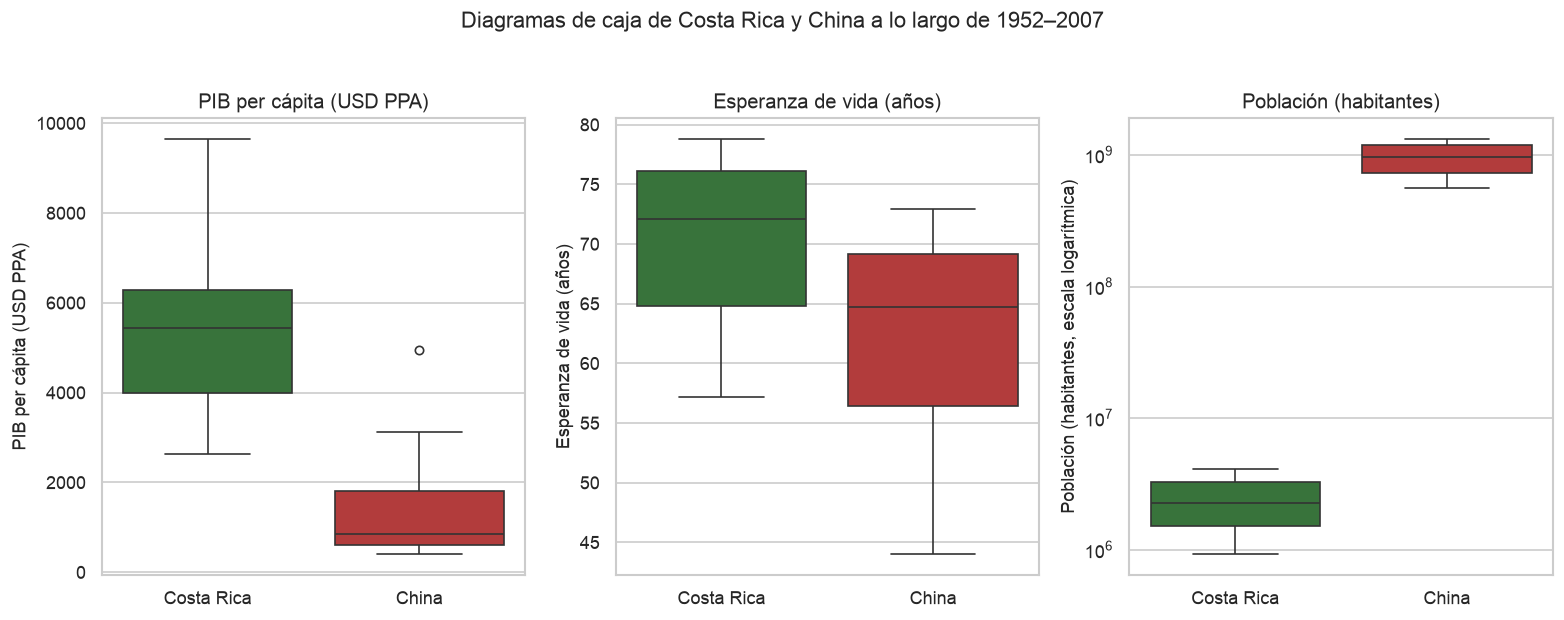

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 5.0))
colores = {"Costa Rica": "#2E7D32", "China": "#C62828"}

for ax, variable in zip(axes, VARIABLES):
    sns.boxplot(
        data=paises,
        x="country",
        y=variable,
        order=PAISES,
        hue="country",
        hue_order=PAISES,
        palette=colores,
        legend=False,
        ax=ax,
        fliersize=5,
    )
    ax.set_title(ETIQUETAS[variable])
    ax.set_xlabel("")
    ax.set_ylabel(ETIQUETAS[variable])
    if variable == "pop":
        ax.set_yscale("log")
        ax.set_ylabel("Población (habitantes, escala logarítmica)")

fig.suptitle(
    "Diagramas de caja de Costa Rica y China a lo largo de 1952–2007",
    fontsize=13,
    y=1.03,
)
fig.tight_layout()
plt.show()


In [11]:
def listar_atipicos(datos: pd.DataFrame, variable: str, grupo: str | None = None) -> pd.DataFrame:
    piezas = []
    if grupo is None:
        bloques = [(None, datos)]
    else:
        bloques = list(datos.groupby(grupo))
    for nombre, bloque in bloques:
        q1, q3 = bloque[variable].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        marca = bloque[(bloque[variable] < lo) | (bloque[variable] > hi)].copy()
        marca["cerca_inferior"] = lo
        marca["cerca_superior"] = hi
        if nombre is not None:
            marca["grupo"] = nombre
        piezas.append(marca)
    if not piezas:
        return pd.DataFrame()
    return pd.concat(piezas, ignore_index=True)


print("Atípicos de PIB per cápita en 2007 (regla de Tukey, dentro de ese corte)")
atip_gdp_2007 = listar_atipicos(corte_2007, "gdpPercap")
display(
    atip_gdp_2007[["country", "continent", "gdpPercap", "cerca_superior"]]
    .sort_values("gdpPercap", ascending=False)
    .round(2)
)

print("Atípicos de población en 2007")
atip_pop_2007 = listar_atipicos(corte_2007, "pop")
display(
    atip_pop_2007[["country", "continent", "pop", "cerca_superior"]]
    .sort_values("pop", ascending=False)
    .round(0)
)

print("Atípicos dentro de la serie de cada país (12 observaciones)")
for variable in VARIABLES:
    hallados = listar_atipicos(paises, variable, grupo="country")
    print(f"\n{ETIQUETAS[variable]}: {len(hallados)} atípico(s)")
    if len(hallados):
        display(
            hallados[["country", "year", variable, "cerca_inferior", "cerca_superior"]].round(2)
        )


Atípicos de PIB per cápita en 2007 (regla de Tukey, dentro de ese corte)


,country,continent,gdpPercap,cerca_superior
3,Norway,Europe,49357.19,42584.83
1,Kuwait,Asia,47306.99,42584.83
2,Singapore,Asia,47143.18,42584.83
0,United States,Americas,42951.65,42584.83


Atípicos de población en 2007


,country,continent,pop,cerca_superior
7,China,Asia,1.318683e+09,71263054.0
8,India,Asia,1.110396e+09,71263054.0
5,United States,Americas,3.011399e+08,71263054.0
9,Indonesia,Asia,2.235470e+08,71263054.0
3,Brazil,Americas,1.900106e+08,71263054.0
11,Pakistan,Asia,1.692706e+08,71263054.0
6,Bangladesh,Asia,1.504483e+08,71263054.0
2,Nigeria,Africa,1.350312e+08,71263054.0
10,Japan,Asia,1.274680e+08,71263054.0
4,Mexico,Americas,1.087009e+08,71263054.0


Atípicos dentro de la serie de cada país (12 observaciones)

PIB per cápita (USD PPA): 1 atípico(s)


,country,year,gdpPercap,cerca_inferior,cerca_superior
0,China,2007,4959.11,-1212.4,3630.08



Esperanza de vida (años): 0 atípico(s)

Población (habitantes): 0 atípico(s)


## 5. Interpretación analítica y diagnóstico

### 5.1 Simetría de las tres variables en el panel completo

La forma se juzga con tres piezas concordantes: el signo de (media − mediana), la simetría de la caja (¿\(Q_3 - Q_2\) iguala a \(Q_2 - Q_1\)?) y el coeficiente de asimetría de Fisher. Un diagrama de caja simétrico tiene la mediana cerca del centro de la caja y bigotes de longitud parecida. Cuando la cerca inferior cae por debajo del mínimo posible de la variable, el bigote inferior se corta en el dato y la asimetría se concentra en el lado alto.

**Esperanza de vida.** Media 59.47 años, mediana 60.71, diferencia −1.24 años. El tramo inferior de la caja mide 12.51 años y el superior 10.13: la caja se alarga levemente hacia abajo. Fisher = −0.25. La distribución es cercana a la simetría, con una cola izquierda moderada. Esa cola corresponde a periodos y países de mortalidad muy alta; el mínimo del panel es Ruanda en 1992 (23.60 años). El máximo es Japón en 2007 (82.60 años). En el corte de 2007 la asimetría negativa se acentúa (media 67.01, mediana 71.94): la mediana ya está en el rango de los países de transición avanzada, y la media la arrastran hacia abajo los países del extremo inferior, concentrados en África (media continental 54.81 años, mediana 52.93).

**PIB per cápita.** Media 7 215 USD, mediana 3 532 USD. La media no representa el país típico: lo hace la mediana, cerca de 3 500 USD. El tramo superior de la caja (5 794 USD) es más del doble del inferior (2 330 USD). Fisher = 3.85. Es una asimetría positiva fuerte. El bigote inferior no puede reflejar una cola izquierda real, porque la cerca de Tukey queda en −10 983 USD y el PIB per cápita no toma valores negativos; el mínimo observado es la República Democrática del Congo en 2002 (241 USD). Toda la cola, y todos los atípicos, están del lado de los ingresos altos. El diagrama de 2007 repite el patrón dentro de cada continente: en África, América, Asia y Europa la media supera a la mediana.

**Población.** Media 29.60 millones, mediana 7.02 millones. Fisher = 8.34. La caja es estrecha si se mira en la escala de los cientos de millones, porque unos pocos países muy grandes estiran el eje. Es la asimetría propia de una variable de tamaño: hay muchos países chicos o medianos y una cola derecha de gigantes demográficos. El mínimo es Santo Tomé y Príncipe en 1952 (60 011 habitantes) y el máximo es China en 2007 (1 318.7 millones).

En los tres casos la mediana es más fiel que la media como “valor típico” cuando la asimetría es marcada. Para el PIB per cápita y la población, reportar solo la media exagera el nivel del país mediano.

### 5.2 Valores atípicos

**Esperanza de vida del panel: ningún atípico formal.** La cerca inferior es 14.23 años y la superior 104.82. Ruanda 1992 (23.60 años) queda dentro de la cerca. Eso no significa que 23.6 años sea un valor ordinario. El IQR del panel es amplio (22.65 años) porque mezcla África con Europa y 1952 con 2007; una regla que usa ese IQR necesita desviaciones enormes para declarar un atípico. La ausencia de puntos fuera de las cercas describe la regla de Tukey aplicada a un panel heterogéneo, no una homogeneidad sustantiva. En 2007 tampoco hay atípicos de esperanza de vida: África entera forma una caja más baja, no un puñado de puntos sueltos. El diagrama por continente es, en ese sentido, más informativo que el diagrama del panel mezclado.

**PIB per cápita del panel: 143 atípicos, todos superiores** a la cerca de 21 511 USD (8.4 % de las observaciones). El extremo es Kuwait en 1957 (113 523 USD). Kuwait aparece de forma reiterada en la cola, junto con otras economías petroleras de población relativamente pequeña y, en los cortes recientes, con economías de alto ingreso (Noruega, Singapur, Estados Unidos). En el solo año 2007 la cerca baja en exigencia relativa del subconjunto y quedan cuatro atípicos: Noruega (49 357 USD), Kuwait (47 307), Singapur (47 143) y Estados Unidos (42 952). No hay atípicos inferiores en ningún corte revisado. La lectura económica es directa: la cola derecha mezcla rentas de recursos naturales y productividad alta; no es un error de captura.

**Población del panel: 208 atípicos superiores** a 44.8 millones. China e India ocupan el extremo, y en 2007 quince países superan la cerca de ese año (71.3 millones), desde China e India hasta Etiopía. Aquí el “atípico” no es una anomalía: es el hecho demográfico de que la distribución de países es desigual. China es, a la vez, el máximo del panel y un atípico sistemático en casi todos los años.

**Series nacionales.** Costa Rica no tiene atípicos de Tukey en ninguna de las tres variables: las tres trayectorias son graduales y la caja las cubre. China tiene un solo atípico nacional, el PIB per cápita de 2007 (4 959 USD), por encima de la cerca superior de su propia serie (3 630 USD). No es un dato corrupto. Es el registro en el que el crecimiento posterior a la apertura sale del patrón histórico 1952–2002, dominado por niveles bajos. Con doce puntos, la regla de Tukey tiene poca potencia: un quiebre puede ser real y aun así caer dentro de las cercas. Eso ocurre con la esperanza de vida china, que pasa de 50.55 años en 1957 a 44.50 en 1962. El punto no es atípico formal, pero es el quiebre más claro de la serie y coincide con la hambruna de 1959–1961. El diagrama de caja no sustituye la lectura de la serie temporal.

### 5.3 Qué muestran los diagramas de caja de 2007

En esperanza de vida, Europa es la caja más alta y más comprimida (media 77.65, mediana 78.61, desviación estándar 2.98 años): los países europeos de 2007 se parecen entre sí. América se sitúa debajo, todavía alta y relativamente compacta (media 73.61, mediana 72.90). Asia tiene mediana alta (72.40) pero más dispersión y un bigote inferior largo: conviven Japón (82.60, el máximo mundial) y países de mortalidad todavía elevada. África es la caja baja del gráfico (media 54.81, mediana 52.93) y explica la mayor parte de la cola izquierda del panel. Oceanía no se interpreta como distribución: solo hay dos observaciones.

En PIB per cápita el orden de las medianas no coincide con el de las medias, precisamente por la asimetría. Europa queda claramente por encima. Asia y América tienen cajas amplias y varios puntos por encima del bigote superior. África concentra la masa de ingresos bajos; su media (3 089 USD) está inflada respecto de la parte central de su caja por una cola derecha interna. El gráfico justifica usar la mediana, y no la media, cuando se dice “el país típico” de un continente.

### 5.4 Conclusiones del contraste Costa Rica–China

Las discrepancias no se reducen a un país “mejor” en bloque. Cada variable cuenta una diferencia estructural distinta.

**Volumen poblacional.** La razón media de población es 399 a 1, y en 2007 sigue en 319 a 1. China es el máximo del panel y un atípico demográfico permanente; Costa Rica permanece durante todo el periodo dentro del orden de unos pocos millones (de 0.93 millones en 1952 a 4.13 millones en 2007). Esa escala cambia el significado del promedio nacional. El dato chino agrega regiones de desarrollo muy desigual; el dato costarricense corresponde a un país territorialmente pequeño y demográficamente homogéneo en comparación. Por eso, en escala lineal, la población china domina cualquier diagrama de caja mundial y la caja costarricense desaparece contra el cero; en escala logarítmica las dos cajas se distinguen y la distancia vertical sigue siendo de unos dos órdenes de magnitud. Costa Rica tampoco se acerca a la cerca de atípicos del panel.

**Estructura económica e ingreso por persona.** En el promedio del periodo, el PIB per cápita costarricense (media 5 449 USD, mediana 5 446 USD) casi no muestra asimetría: media y mediana coinciden y no hay atípicos. El coeficiente de variación es 0.37. China parte de 400 USD en 1952, mantiene una mediana histórica de solo 852 USD y termina en 4 959 USD en 2007, único atípico de su serie. Su coeficiente de variación es 0.92: el nivel medio está dominado por el tramo final. Entre 1952 y 2007 China multiplica el PIB per cápita por 12.4 y Costa Rica por 3.7. La brecha de medias (Costa Rica / China = 3.66) se reduce a 1.94 en 2007. El patrón encaja con dos estructuras distintas: China combina una base agrícola de muy bajo producto por persona con una industrialización exportadora acelerada después de las reformas de 1978; Costa Rica recorre el periodo desde un ingreso medio, con una caída visible en 1982 (de 5 927 USD en 1977 a 5 263), coincidente con la crisis de la deuda en América Latina, y una recuperación posterior apoyada en agricultura de exportación, turismo y servicios. La caída de 1982 no llega a ser atípica: está dentro de una serie corta y ascendente.

**Región y esperanza de vida.** Costa Rica pertenece a la caja alta de América y China a una Asia heterogénea. La ventaja media de Costa Rica es 8.40 años (70.18 frente a 61.79). En 2007 se ha reducido a 5.82 años (78.78 frente a 72.96), porque China gana más años en el periodo (+28.96 frente a +21.58) al partir de un piso mucho más bajo (44.00 años en 1952, frente a 57.21 en Costa Rica). La serie costarricense es más estable (coeficiente de variación 0.11 frente a 0.17) y monótona al alza. La serie china no lo es: el retroceso de 1962 interrumpe la mejora de los años cincuenta y recuerda que el promedio de la serie nacional es sensible a un choque de mortalidad. La posición relativa de Costa Rica —ya en 1952 por encima de la media del panel, y en 2007 en la parte alta de América— es coherente con una prioridad temprana de salud pública, en particular la extensión de la seguridad social y el peso del gasto social en un país que abolió el ejército en 1948. China, en cambio, logra la mayor parte de su ganancia de longevidad junto con la transición demográfica y el crecimiento posterior a 1980, después de haber absorbido el quiebre de inicios de los sesenta.

**Síntesis.** El diagrama de caja y las medidas de posición cuentan la misma historia. El mundo del panel es asimétrico a la derecha en ingreso y en población, y levemente asimétrico a la izquierda en longevidad; los atípicos de ingreso son economías ricas o petroleras, y los atípicos de población son los países grandes, China en primer lugar. Entre los dos países elegidos, Costa Rica ofrece el nivel de vida más alto y la trayectoria más regular; China ofrece la escala demográfica extrema y la aceleración económica más intensa, visible como atípico dentro de su propia serie de PIB per cápita en 2007. La convergencia parcial de 1952 a 2007 es real en ingreso por persona y en esperanza de vida, y no alcanza a borrar ninguna de las dos brechas.


## Fuente de los datos

Gapminder Foundation, archivo `gapminder_all.csv` (142 países; PIB per cápita, esperanza de vida y población en los quinquenios 1952–2007). El archivo original está en formato ancho; el análisis usa la versión larga, con una observación por país y año.
